## 0. Importar librerías externas

Otra opción es utilizar Keras directamente desde el framework Tensorflow. Si el backend que vamos a utilizar es Tensorflow, esta opción está más optimizada y suele proporcionar mejores resultados.

Tanto Keras-core como la versión de Keras que se encuentra en framework Tensorflow son totalmente compatibles y no requieren modificaciones en la implementación del programa.

In [ ]:
!pip install keras_unet_collection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from keras_unet_collection import models, losses

Verificamos si el backend (Tensorflow) esta utilizando la GPU

In [ ]:
tf.test.gpu_device_name()

'/device:GPU:0'

## 1. Preparación del conjunto de datos de entrenamiento

### 1.1. Importando el conjunto de datos

In [ ]:
# Descargamos el conjunto de datos en el almacenamiento temporal de Google Colab
!curl -L -o images.npz https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
!curl -L -o masks.npz https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/masks.npz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9601k  100 9601k    0     0  6243k      0  0:00:01  0:00:01 --:--:-- 6243k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 92714  100 92714    0     0   169k      0 --:--:-- --:--:-- --:--:--  169k


### 1.2. Limpieza de los datos

Cuando trabajamos con conjuntos de datos reales, es muy frecuente que algunos de los ejemplos esten corruptos o incompletos y haya que eliminarlos.

In [ ]:
# Load images
images = np.load("images.npz")["images"]
masks = np.load("masks.npz")["masks"]

# Removing unnecesary parts
images = images[:, 24:]
masks = masks[:, 24:]

# Convert to grayscale
images = images[:,:,:,0]

# Maybe need to shuffle images and convert mask to boolean values?
# AI generated code to improve the performance after tests
images = images / 255.0 # if rgb, convert that to a range from 0 to 1
masks = (masks > 0).astype("float32")

# Add pad to iamges and masks so they have a resolution of 320x320
def pad(x):
    return np.pad(x[..., None], ((0, 0), (22, 22), (10, 10), (0, 0)))

print(images.shape)
print(masks.shape)

(208, 276, 300)
(208, 276, 300)


### 1.3. Creación de un Dataset con Keras

Otro de los aspectos importantes cuando utilizamos un conjunto de datos de imágenes es normalizar su tamaño. Lo habitual cuando trabajamos con imágenes reales es que tengan diferentes tamaños.

In [ ]:
images = pad(images)
masks = pad(masks)

# Shuffling dataset
idx = np.random.permutation(len(images))
images = images[idx]
masks = masks[idx]

### 1.5. División del conjunto de datos

Cuando abordamos la resolución de un problema real aplicando Inteligencia Artificial / Machine Learning / Deep Learning, debemos dividir el conjunto de datos en 3 subconjuntos:
* **Subconjunto de entrenamiento** (`train_ds`): Contiene apróximadamente el 60-80% de los datos. Este subcojunto se utiliza para entrenar el algoritmo.
* **Subconjunto de validación** (`val_ds`): Contiene apróximadamente el 10-20% de los datos. Este subcojunto se utiliza para validar el comportamiento del algoritmo durante el proceso de entrenamiento.
* **Subconjunto de pruebas** (`test_ds`): Contiene apróximadamente el 10-20% de los datos. Este subconjunto se utilizar para validar el comportamiento del algoritmo entrenado final. Su función es determinar si el modelo se comporta correctamente para ejemplos que no ha visto nunca.

Esta división y modo de actuar nos permite evitar problemas graves como el sobreentrenamiento u _overfitting_.

Keras nos permite dividir de manera muy sencilla el conjunto de datos en el subconjunto de entrenamiento y validación.

In [ ]:
# Divide dataset - 80% will be used for actual training and 10% for val (will be assigned later)
X_train = images[:180]
y_train = masks[:180]

# Small dataset, 10%, 28 images will be used for test at the end
X_test = images[180:]
y_test = masks[180:]

## 2. Definicion de la arquitectura de la Red Neuronal Artificial

In [ ]:
# Used AI for these functions
bce = tf.keras.losses.BinaryCrossentropy()

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denominator = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)

    return (2.0 * intersection + smooth) / (denominator + smooth)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

# dice_coef: Mide la superposición entre predicción y máscara real. Ideal para segmentación con clases desbalanceadas.
# iou_coef: Similar al Dice pero penaliza más los falsos positivos y negativos.
# bce_dice_loss: Combina Binary Crossentropy (buena para convergencia) con Dice Loss (buena para precisión de segmentación).
# smooth: Evita divisiones por cero cuando no hay píxeles positivos.

In [ ]:
# model = models.unet_2d(
#     input_size=(320,320,1), #(height, width, channels) 320x320, 1 canal (grayscale)
#     filter_num=[64,128,256,512],
#     n_labels=1, # Number of clases. In this case: 0 = background 1 = spleen
# )

#Filter_num -- Número de filtros en cada nivel del encoder.
# layer1 → 64 filters
# layer2 → 128
# layer3 → 256
# layer4 → 512

# Más filtros =
# más capacidad
# más memoria

# FROM PREVIOUS EXAMPLES
model = models.unet_2d(
    input_size=(320, 320, 1),
    filter_num=[64, 128, 256, 512],
    n_labels=1,
    output_activation="Sigmoid"
)

## 3. Configuracion de la Red Neuronal Artificial

Para que la Red Neuronal Artificial funcione adecuadamente va a requerir tres componentes adicionales que se seleccionan durante el proceso de compilación:
1. **La función de error**: Se utiliza en el proceso de optimización de los parámetros del modelo para medir el error  producido al modificar el valor de los parámetros del modelo en una dirección determinada
2. **La función de optimización**: Se corresponde con la función encargada de actualizar el valor de los parámetros del modelo en una dirección determinada en función del resultado de la función de error
3. **Metricas para monitorizar el proceso de entrenamiento**: Es interesante utilizar un conjunto de métricas durante el proceso de entrenamiento de la Red Neuronal Artificial de manera que podamos saber en cada iteración si el valor de los parámetros del modelo es adecuado o se están produciendo problemas como *overfitting*

In [ ]:
# KERAS LOSS FUNCTION
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Small jumps (1e- >current will get the best paraemters slower, but will get the best parameters, biggers jumps will get them faster, but might be a little off or up the sweet spot for the UNet.
#     loss="binary_crossentropy",
#     metrics=[
#         tf.keras.metrics.BinaryAccuracy(name="bin_acc"), # Special function recomended from keras for binary segmentation - more optimized than regular accuracy.
#         dice_coef, # Calculate dice coeficient
#         iou_coef
#     ]
# )

# AI GENEREATED LOSS FUNCTION
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Small jumps will get the best paraemters slower, but will get the best parameters, biggers jumps will get them faster, but might be a little off or up the sweet spot for the UNet.
#     loss=bce_dice_loss, # Loss function - binary_crossentropy comvined with dice loss.
#     metrics=[
#         tf.keras.metrics.BinaryAccuracy(name="bin_acc"), # Special function recomended from keras for binary segmentation - more optimized than regular accuracy.
#         dice_coef, # Calculate dice coeficient
#         iou_coef
#     ]
# )

# ACCURACY METRIC TO COMPARE
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )

# AI generated
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef, iou_coef, tf.keras.metrics.BinaryAccuracy(name="bin_acc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)


Una vez definida la arquitectura de la Red Neuronal Artificial podemos visualizarla junto con el número total de parámetros utilizando el método `summary()`

In [ ]:
model.summary()

Model: "unet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0        │ (None, 320, 320,  │        640 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0_activ… │ (None, 320, 320,  │          0 │ unet_down0_0[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1        │ (None, 320, 320,  │     36,928 │ unet_down0_0_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1_activ… │ (None, 320, 320,  │          0 │ unet_down0_1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_encode_… │ (None, 160, 160,  │          0 │ unet_down0_1_act… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0   │ (None, 160, 160,  │     73,856 │ unet_down1_encod… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0_… │ (None, 160, 160,  │          0 │ unet_down1_conv_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1   │ (None, 160, 160,  │    147,584 │ unet_down1_conv_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1_… │ (None, 160, 160,  │          0 │ unet_down1_conv_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_encode_… │ (None, 80, 80,    │          0 │ unet_down1_conv_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0   │ (None, 80, 80,    │    295,168 │ unet_down2_encod… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0_… │ (None, 80, 80,    │          0 │ unet_down2_conv_… │
│ (ReLU)              │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_1   │ (None, 80, 80,    │    590,080 │ unet_down2_conv_… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_1_… │ (None, 80, 80,    │          0 │ unet_down2_conv_… │
│ (ReLU)              │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down3_encode_… │ (None, 40, 40,    │          0 │ unet_down2_conv_… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down3_conv_0   │ (None, 40, 40,    │  1,180,160 │ unet_down3_encod

 Total params: 8,556,353 (32.64 MB)

 Trainable params: 8,556,353 (32.64 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento de la Red Neuronal Artificial

En este punto ya estamos listos para entrenar nuestra Red Neuronal Artificial invocando el método *fit()*. Una de las capacidades que nos proporciona Keras es la de integrar el proceso de validación en el propio proceso de entrenamiento, para ello, junto con el subconjunto de datos de entrenamiento, debemos proporcionarle a este método el subconjunto de validación.

In [ ]:
history = model.fit(X_train, y_train, batch_size=16, epochs=50, validation_split=0.1)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - bin_acc: 0.9114 - dice_coef: 0.1222 - iou_coef: 0.0651 - loss: 1.5550 - precision: 0.0032 - recall: 7.7463e-04 - val_bin_acc: 0.9286 - val_dice_coef: 0.0926 - val_iou_coef: 0.0486 - val_loss: 1.4739 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - bin_acc: 0.9286 - dice_coef: 0.0557 - iou_coef: 0.0288 - loss: 1.4042 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_bin_acc: 0.9286 - val_dice_coef: 0.0468 - val_iou_coef: 0.0240 - val_loss: 1.3072 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - bin_acc: 0.9286 - dice_coef: 0.0981 - iou_coef: 0.0522 - loss: 1.1905 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_bin_acc: 0.9286 - val_dice_coef: 0.2164 - val_iou_coef: 0.1214 - val_loss: 0.9383 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - bin_acc: 0.9286 - dice

En la variable ***history*** se almacenan varios valores importantes:
* El valor de los parámetros del modelo después del entrenamiento
* La lista de *epochs* llevados a cabo
* Un diccionario con el error producido en cada *epoch* en el conjunto de datos de entreanamiento y validación

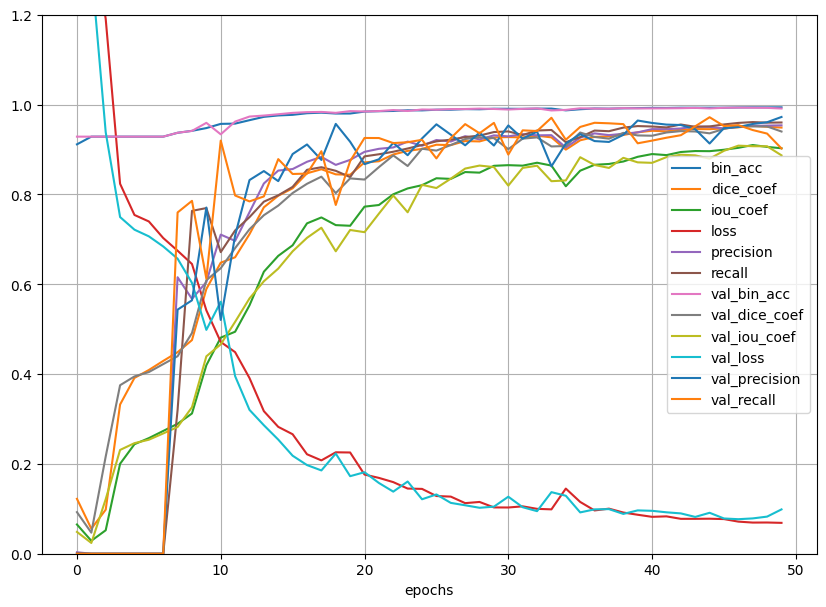

In [ ]:
pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.grid(True)
plt.gca().set_ylim(0, 1.2)
plt.xlabel("epochs")
plt.show()

# Loss - lower values ​​are better
# dice_coef, iou_coef, and bin_acc - hihger values are better.

# Why accuracy alone is not a good metric?
# Imagine a 100,000-pixel image where only 2,000 pixels belong to the object and 98,000 are background.
# If the model predicts everything as background, it can achieve very high accuracy, but DICE and IoU will perform very poorly because it failed to detect the object.

# Why dice iou stays in the bottom?
# - Significant imbalance between background and object.
# - Poorly processed or misaligned masks.
# - A model that's too simplistic for the problem.
# - The loss is helping to reduce numerical error, but not to improve the actual overlap.

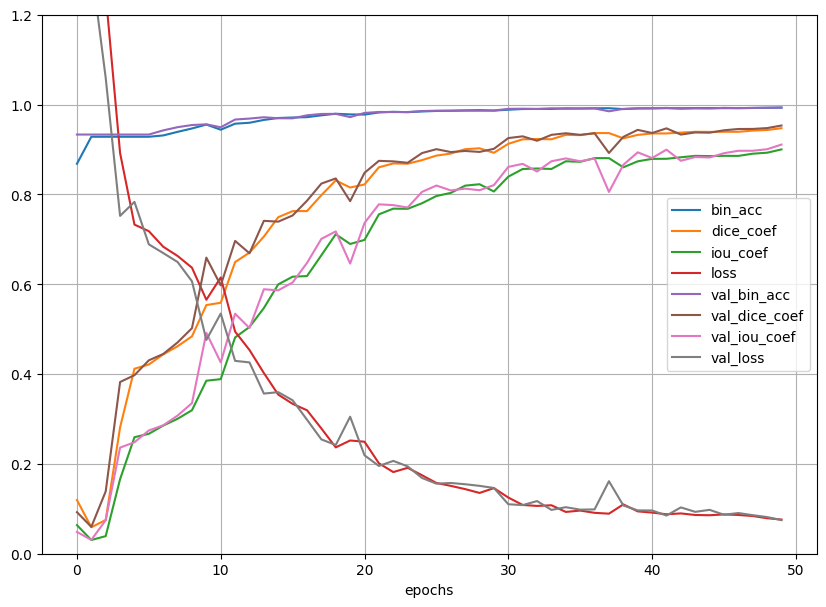

In [ ]:
# New adjusted model, compile, shuffling and gray scale?
pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.grid(True)
plt.gca().set_ylim(0, 1.2)
plt.xlabel("epochs")
plt.show()

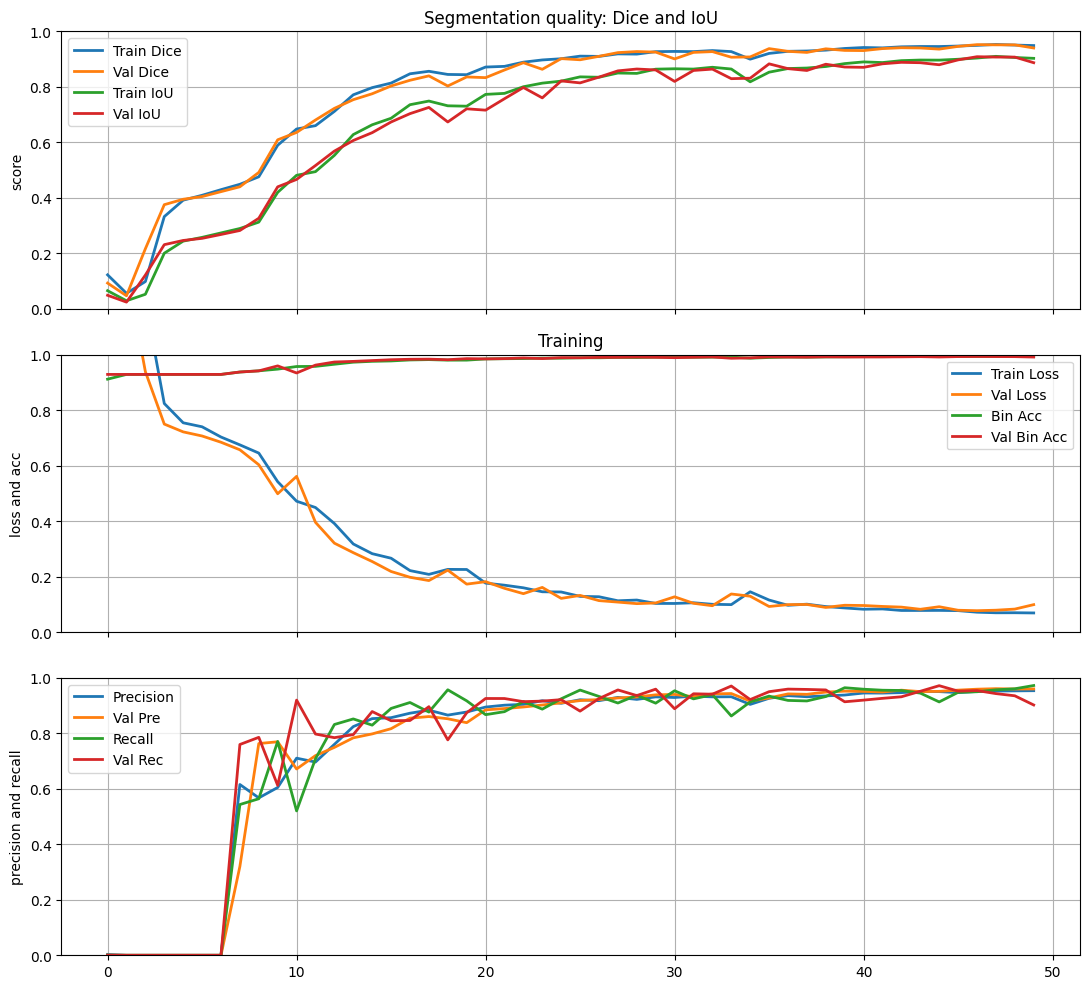

In [ ]:
# Now with trimmed Images and separated graph
hist_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

seg_cols = ['dice_coef', 'val_dice_coef', 'iou_coef', 'val_iou_coef']
hist_df[seg_cols].plot(ax=axes[0], linewidth=2)

# Quality
axes[0].set_title("Segmentation quality: Dice and IoU")
axes[0].set_ylabel("score")
axes[0].set_ylim(0, 1.0)
axes[0].grid(True)
axes[0].legend([
    'Train Dice', 'Val Dice',
    'Train IoU', 'Val IoU'
])

# Training
loss_cols = ['loss', 'val_loss', 'bin_acc', 'val_bin_acc']
hist_df[loss_cols].plot(ax=axes[1], linewidth=2)

axes[1].set_title("Training")
axes[1].set_ylabel("loss and acc")
axes[1].set_ylim(0, 1.0)
axes[1].set_xlabel("epochs")
axes[1].grid(True)
axes[1].legend(['Train Loss', 'Val Loss', 'Bin Acc', 'Val Bin Acc'])


# precision recall
pre_call = ['precision', 'recall', 'val_precision', 'val_recall']
hist_df[pre_call].plot(ax=axes[2], linewidth=2)

axes[2].set_ylabel("precision and recall")
axes[2].set_ylim(0, 1.0)
axes[2].grid(True)
axes[2].legend([
    'Precision', 'Val Pre',
    'Recall', 'Val Rec'
])


plt.tight_layout()
plt.show()

## 5. Guardar el modelo en disco

Con Keras generamos la arquitectura de la red neuronal, la entrenamos y después la evaluamos. Existen diferentes alternativas a la hora de exportar el modelo entrenado (https://keras.io/getting_started/faq/#what-are-my-options-for-saving-models), en este caso se expone una de las más utilizadas.

De la forma que se indica a continuación, vamos a exportar en un fichero los siguientes componentes de la red neuronal:
* La arquitectura del modelo
* Los parámetros del modelo
* Los hiperparámetros del modelo
* Las métricas

In [ ]:
# Save the model in disk
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/IMPACT/models")

Una vez ejecutada la celda anterior, generará un fichero `modelo_fcnn_cats_vs_dogs` que puede utilizarse para transportarlo a otro sistema y predecir con nuevos ejemplos. La forma en la que puedes importar este fichero para predecir con nuevos ejemplos es la siguiente:

In [ ]:
# Load model in disk
model_disk = keras.models.load_model("/content/drive/MyDrive/IMPACT/models")

## 6. Predicción de nuevos ejemplos

In [ ]:
# Evaluate on test dataset - evaluate does the same as predict, but now with metrics so we can take conclusions
evaluation_result = model.evaluate(X_test, y_test)

# Print metrics of evaluation (example loss and accuracy)
print("Loss:", evaluation_result[0])
print("Accuracy:", evaluation_result[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - bin_acc: 0.9919 - dice_coef: 0.9355 - iou_coef: 0.8788 - loss: 0.0929 - precision: 0.9793 - recall: 0.9052
Loss: 0.09294625371694565
Accuracy: 0.9354920387268066


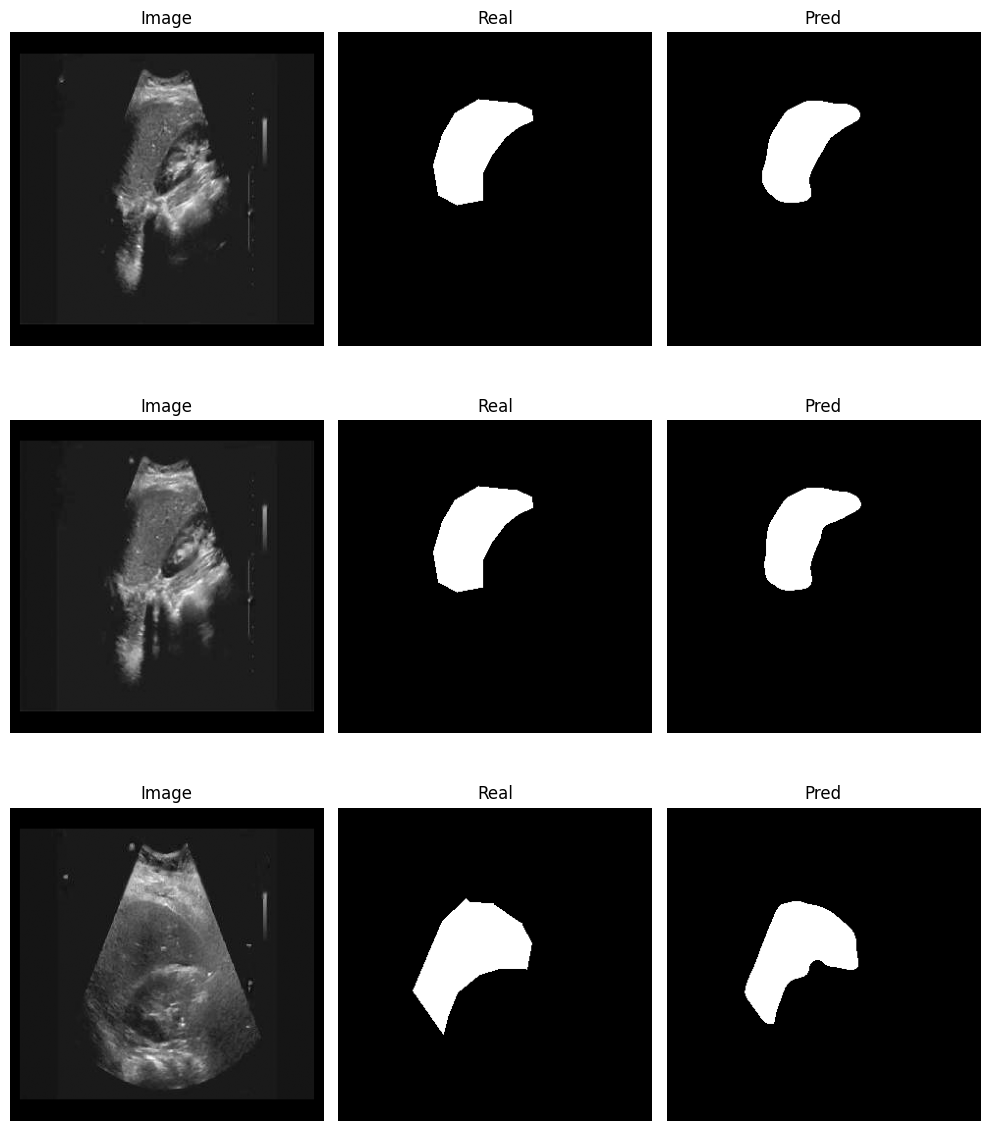

In [ ]:
# Used AI for the show function
plt.figure(figsize=(10, 12))

for i in range(3):
    img = X_test[i]
    true_mask = y_test[i]
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)#exapnd_dims because the model expects a batch (set of images), function expands the original images to add the batch value (just 1 image in the batch) - verbose 0 removes the progress bar for keras
    pred_mask = (pred[0] > 0.5).astype(np.uint8)

    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Real")
    plt.axis("off")

    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Pred")
    plt.axis("off")

plt.tight_layout()
plt.show()


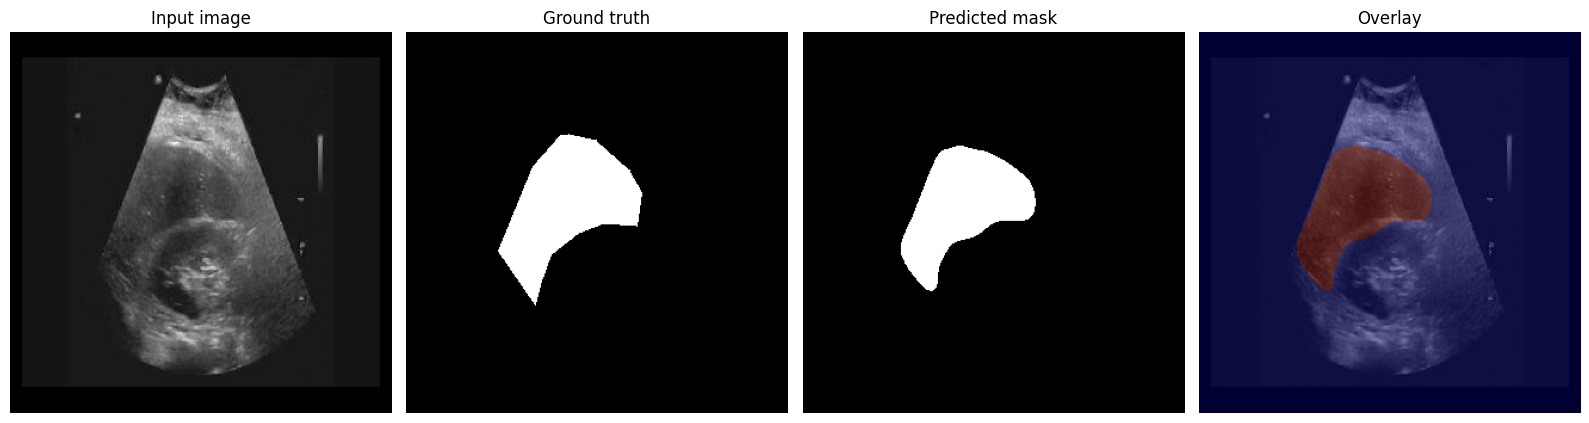

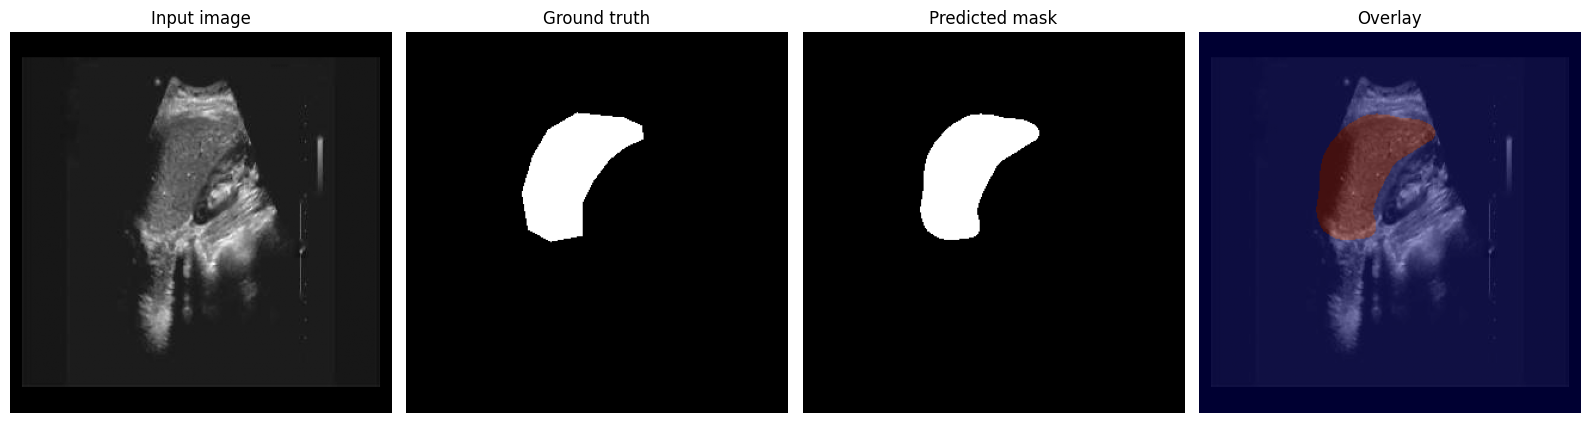

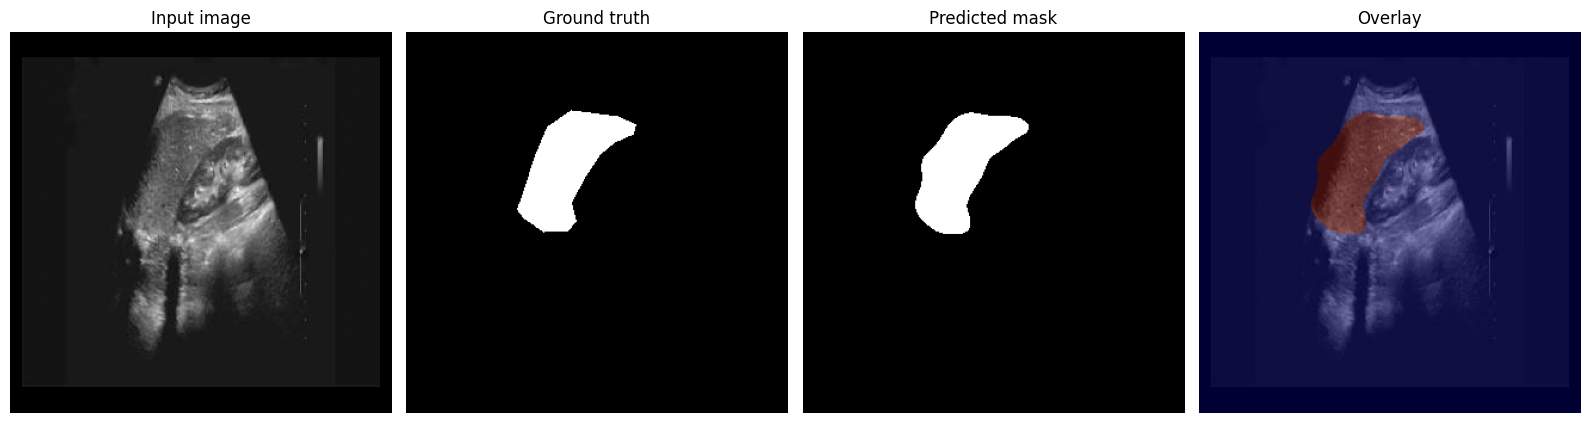

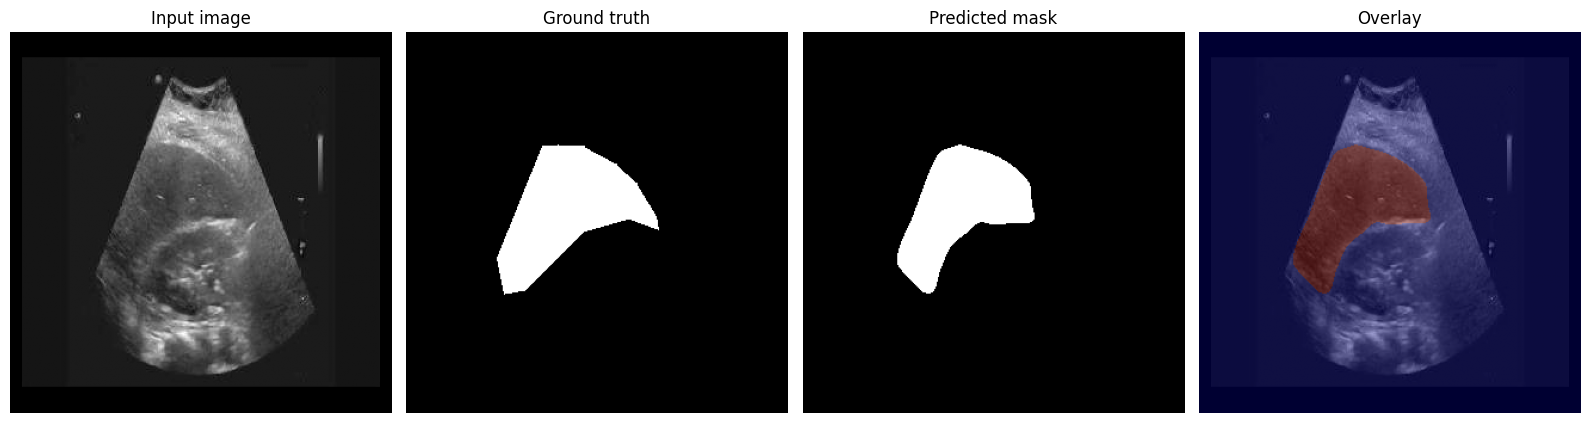

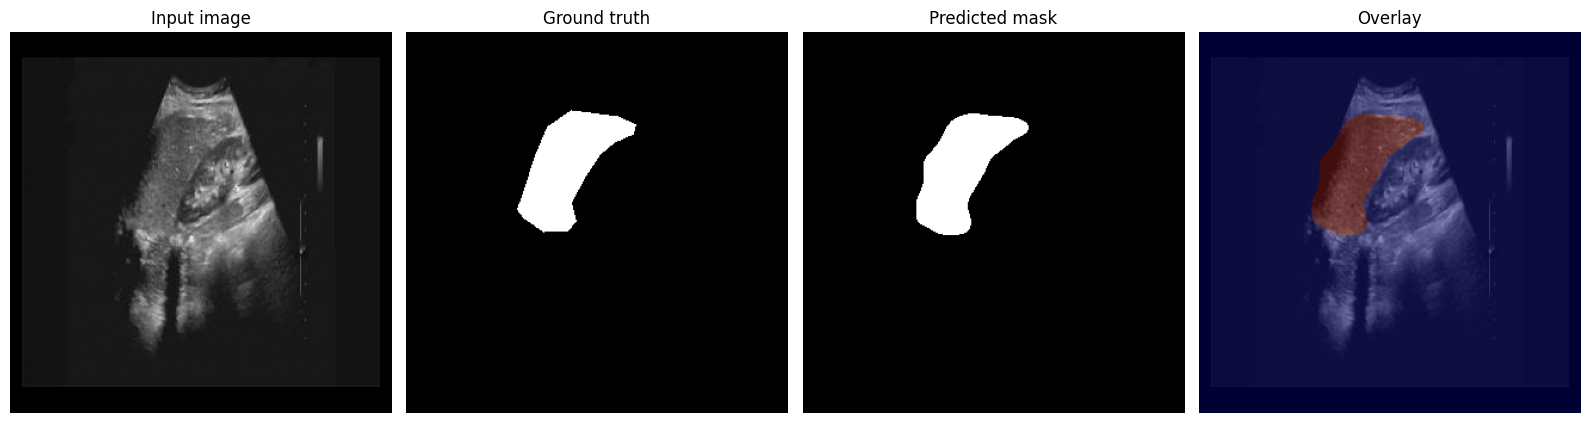

In [ ]:
for i in range(5):
    idx = np.random.randint(0, len(X_test))
    image = X_test[idx]
    mask = y_test[idx]

    pred = model.predict(np.expand_dims(image, axis=0), verbose=0)
    prediction = pred[0]                    # remove batch dimention
    prediction_bin = (prediction > 0.5).astype(np.uint8) # Converts the probabilistic output of the model into a binary mask of 0s and 1s.

    fig, axs = plt.subplots(1, 4, figsize=(16, 6))

    axs[0].imshow(image.squeeze(), cmap="gray")
    axs[0].set_title("Input image")
    axs[0].axis("off")

    axs[1].imshow(mask.squeeze(), cmap="gray")
    axs[1].set_title("Ground truth")
    axs[1].axis("off")

    axs[2].imshow(prediction_bin.squeeze(), cmap="gray")
    axs[2].set_title("Predicted mask")
    axs[2].axis("off")

    axs[3].imshow(image.squeeze(), cmap="gray")
    axs[3].imshow(prediction_bin.squeeze(), cmap="jet", alpha=0.4)
    axs[3].set_title("Overlay")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()
